In [1]:
# More epochs + more data = better accuracy
from datasets import load_dataset
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score
import torch

dataset = load_dataset("stanfordnlp/imdb")

# Zyada data — 8000 train, 2000 test
small_train = dataset['train'].shuffle(seed=42).select(range(8000))
small_test = dataset['test'].shuffle(seed=42).select(range(2000))

tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
def tokenize(batch):
    return tokenizer(batch['text'], truncation=True, padding='max_length', max_length=256)

train_tok = small_train.map(tokenize, batched=True)
test_tok = small_test.map(tokenize, batched=True)
train_tok.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
test_tok.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])

model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    return {'accuracy': accuracy_score(labels, preds), 'f1': f1_score(labels, preds, average='weighted')}

args = TrainingArguments(
    output_dir='./results2',
    num_train_epochs=5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    warmup_steps=200,
    weight_decay=0.01,
    learning_rate=2e-5,
    report_to='none'
)

trainer = Trainer(model=model, args=args, train_dataset=train_tok, eval_dataset=test_tok, compute_metrics=compute_metrics)
trainer.train()

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=625, training_loss=0.5150080505371094, metrics={'train_runtime': 557.951, 'train_samples_per_second': 71.691, 'train_steps_per_second': 1.12, 'total_flos': 2649347973120000.0, 'train_loss': 0.5150080505371094, 'epoch': 5.0})

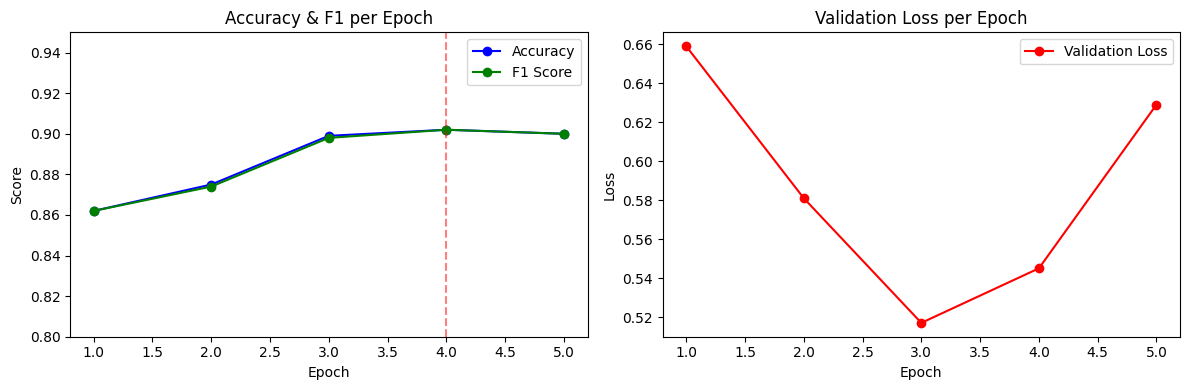

Graph saved!


In [2]:
import matplotlib.pyplot as plt

epochs = [1, 2, 3, 4, 5]
accuracy = [0.862, 0.875, 0.899, 0.902, 0.900]
f1 = [0.862, 0.874, 0.898, 0.902, 0.900]
val_loss = [0.659, 0.581, 0.517, 0.545, 0.629]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, accuracy, 'b-o', label='Accuracy')
axes[0].plot(epochs, f1, 'g-o', label='F1 Score')
axes[0].set_title('Accuracy & F1 per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Score')
axes[0].legend()
axes[0].set_ylim([0.8, 0.95])
axes[0].axvline(x=4, color='red', linestyle='--', alpha=0.5, label='Best Model')

axes[1].plot(epochs, val_loss, 'r-o', label='Validation Loss')
axes[1].set_title('Validation Loss per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_results.png', dpi=150)
plt.show()
print("Graph saved!")